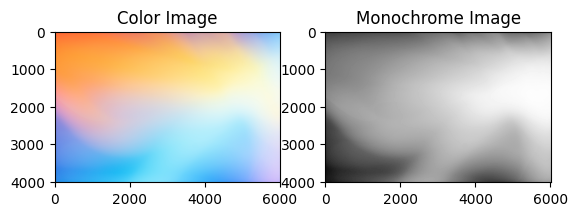

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

# Specify the path to your image
image_path = '/content/vivid 2-blurred-colorful-background (1).jpg'

# Check if the file exists
if not os.path.exists(image_path):
    print(f"Error: The file at path {image_path} does not exist.")
else:
    # Load the color image
    image = cv2.imread(image_path)

    # Check if the image was loaded correctly
    if image is None:
        print(f"Error: The image at path {image_path} could not be loaded.")
    else:
        # Convert the color image to grayscale
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

        # Save the monochrome image
        cv2.imwrite('monochrome_image.jpg', gray_image)

        # Display the images
        plt.subplot(1, 2, 1)
        plt.title('Color Image')
        plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

        plt.subplot(1, 2, 2)
        plt.title('Monochrome Image')
        plt.imshow(gray_image, cmap='gray')

        plt.show()


Saving head.png to head (1).png


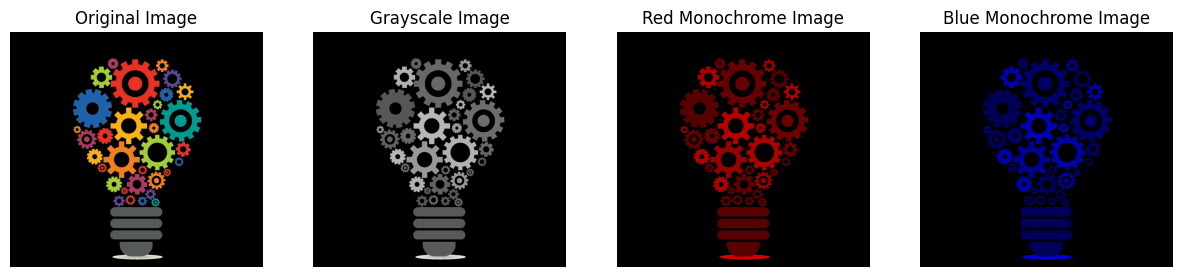

In [ ]:
import cv2
import numpy as np
from google.colab import files
from matplotlib import pyplot as plt

# Upload image
uploaded = files.upload()

# Load the uploaded image
for fn in uploaded.keys():
    img = cv2.imdecode(np.frombuffer(uploaded[fn], np.uint8), cv2.IMREAD_COLOR)
    break

# Convert to grayscale
img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Create red monochrome image
img_red = np.zeros_like(img)
img_red[:, :, 2] = img_gray  # Set red channel to the grayscale intensity

# Create blue monochrome image
img_blue = np.zeros_like(img)
img_blue[:, :, 0] = img_gray  # Set blue channel to the grayscale intensity

# Display the original and monochrome images
plt.figure(figsize=(15, 5))

# Original image
plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

# Grayscale image
plt.subplot(1, 4, 2)
plt.imshow(img_gray, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

# Red monochrome image
plt.subplot(1, 4, 3)
plt.imshow(cv2.cvtColor(img_red, cv2.COLOR_BGR2RGB))
plt.title('Red Monochrome Image')
plt.axis('off')

# Blue monochrome image
plt.subplot(1, 4, 4)
plt.imshow(cv2.cvtColor(img_blue, cv2.COLOR_BGR2RGB))
plt.title('Blue Monochrome Image')
plt.axis('off')

plt.show()


In [ ]:
!pip install matplotlib opencv-python


Please enter the path to the image: /content/book.png


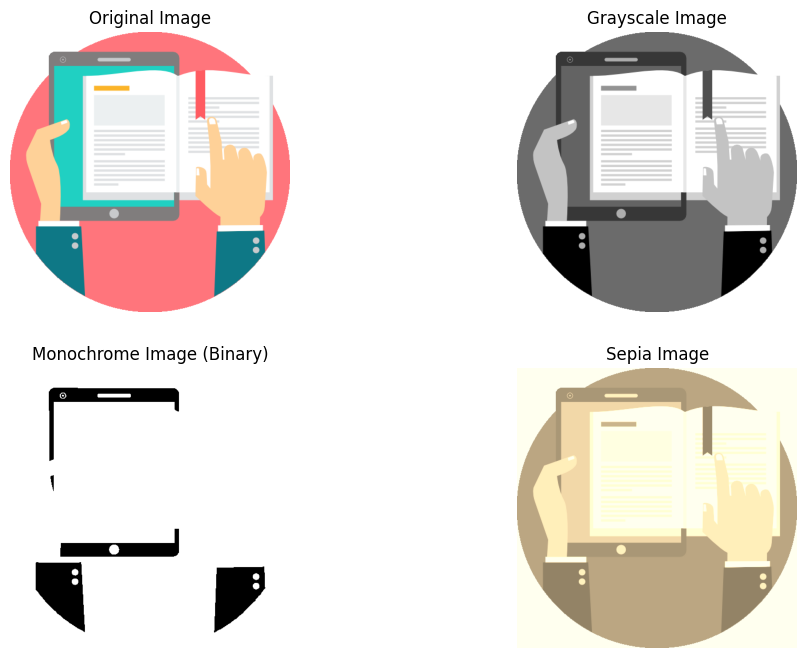

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Function to display images
def display_images(original, grayscale, binary, sepia):
    plt.figure(figsize=(12, 8))

    plt.subplot(2, 2, 1)
    plt.imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(2, 2, 2)
    plt.imshow(grayscale, cmap='gray')
    plt.title('Grayscale Image')
    plt.axis('off')

    plt.subplot(2, 2, 3)
    plt.imshow(binary, cmap='gray')
    plt.title('Monochrome Image (Binary)')
    plt.axis('off')

    plt.subplot(2, 2, 4)
    plt.imshow(sepia)
    plt.title('Sepia Image')
    plt.axis('off')

    plt.show()

# Function to apply sepia filter
def apply_sepia(image):
    sepia_filter = np.array([[0.393, 0.769, 0.189],
                             [0.349, 0.686, 0.168],
                             [0.272, 0.534, 0.131]])
    sepia_image = cv2.transform(image, sepia_filter)
    sepia_image = np.clip(sepia_image, 0, 255)
    return sepia_image

# Main program
if __name__ == "__main__":
    # Ask user to input image path
    image_path = input("Please enter the path to the image: ")

    if image_path:
        # Read the image
        image = cv2.imread(image_path)

        if image is None:
            print("Error: Unable to load image. Please check the path.")
        else:
            # Convert to grayscale
            grayscale_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

            # Convert to binary (monochrome)
            _, binary_image = cv2.threshold(grayscale_image, 127, 255, cv2.THRESH_BINARY)

            # Apply sepia filter
            sepia_image = apply_sepia(image)

            # Display all images
            display_images(image, grayscale_image, binary_image, sepia_image)
    else:
        print("No image path provided!")


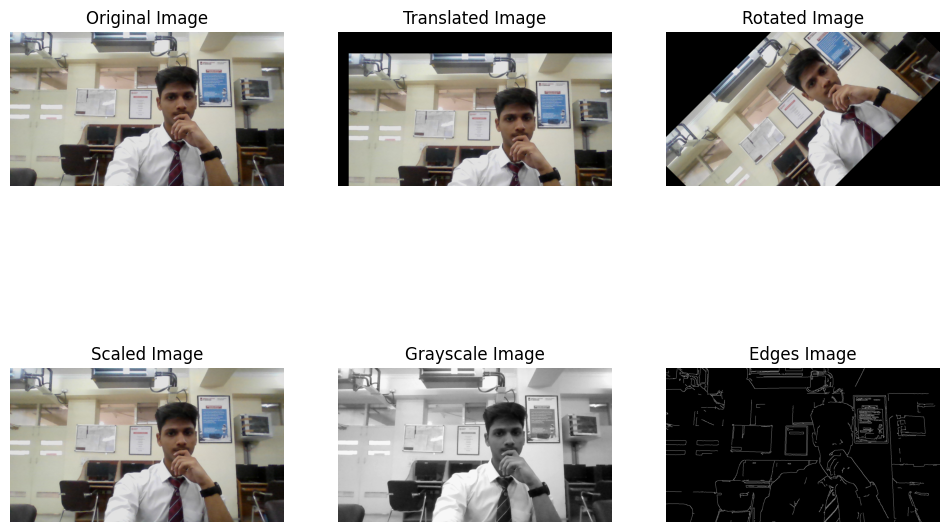

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Function to translate an image
def translate(image, tx, ty):
    rows, cols = image.shape[:2]
    M = np.float32([[1, 0, tx], [0, 1, ty]])
    translated_image = cv2.warpAffine(image, M, (cols, rows))
    return translated_image

# Function to rotate an image
def rotate(image, angle):
    rows, cols = image.shape[:2]
    center = (cols / 2, rows / 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated_image = cv2.warpAffine(image, M, (cols, rows))
    return rotated_image

# Function to scale an image
def scale(image, fx, fy):
    scaled_image = cv2.resize(image, None, fx=fx, fy=fy, interpolation=cv2.INTER_LINEAR)
    return scaled_image

# Function to convert image to grayscale
def to_grayscale(image):
    grayscale_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return grayscale_image

# Function to blur an image
def blur(image, ksize):
    blurred_image = cv2.GaussianBlur(image, (ksize, ksize), 0)
    return blurred_image

# Function to detect edges
def edge_detection(image):
    edges = cv2.Canny(image, 100, 200)
    return edges

# Load an image
image = cv2.imread("/content/WIN_20240410_12_38_26_Pro.jpg")

# Apply transformations
translated_image = translate(image, 50, 100)
rotated_image = rotate(image, 45)
scaled_image = scale(image, 0.5, 0.5)
grayscale_image = to_grayscale(image)
blurred_image = blur(image, 15)
edges_image = edge_detection(grayscale_image)

# Display the images
plt.figure(figsize=(12, 8))
plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(cv2.cvtColor(translated_image, cv2.COLOR_BGR2RGB))
plt.title('Translated Image')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(cv2.cvtColor(rotated_image, cv2.COLOR_BGR2RGB))
plt.title('Rotated Image')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(cv2.cvtColor(scaled_image, cv2.COLOR_BGR2RGB))
plt.title('Scaled Image')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(grayscale_image, cmap='gray')
plt.title('Grayscale Image')
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(edges_image, cmap='gray')
plt.title('Edges Image')
plt.axis('off')

plt.show()



Saving download1.jpeg to download1 (2).jpeg


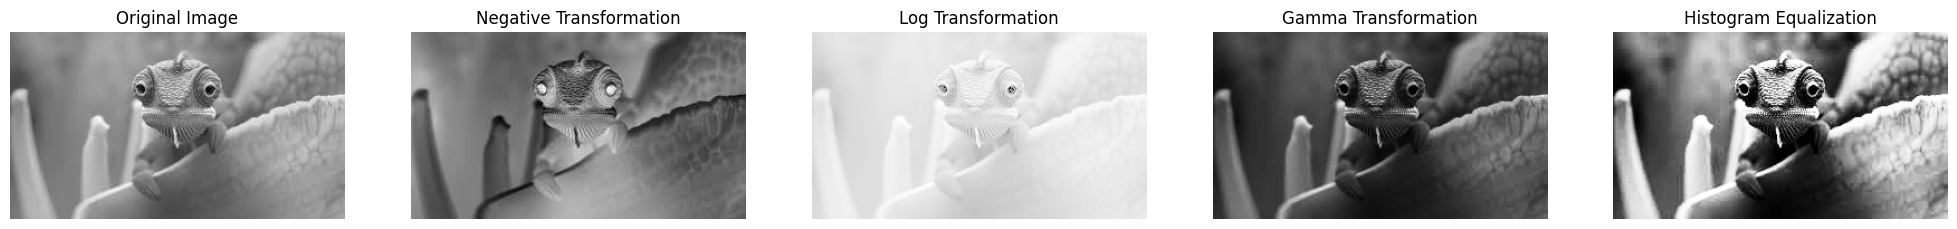

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# Upload image file
uploaded = files.upload()
image_path = next(iter(uploaded.keys()))

# Read image in grayscale mode
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Define constants
c = 1
gamma = 2.2

# Apply transformations
negative_image = 255 - original_image
log_image = c * np.log(1 + original_image.astype(np.float32))
log_image = np.uint8(cv2.normalize(log_image, None, 0, 255, cv2.NORM_MINMAX))
gamma_image = c * np.power(original_image.astype(np.float32), gamma)
gamma_image = np.uint8(cv2.normalize(gamma_image, None, 0, 255, cv2.NORM_MINMAX))
hist_equalized_image = cv2.equalizeHist(original_image)

# Save transformed images
cv2.imwrite('negative_image.jpg', negative_image)
cv2.imwrite('log_image.jpg', log_image)
cv2.imwrite('gamma_image.jpg', gamma_image)
cv2.imwrite('hist_equalized_image.jpg', hist_equalized_image)

# Display original and transformed images
fig, axes = plt.subplots(1, 5, figsize=(25, 5))
axes[0].imshow(original_image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')
axes[1].imshow(negative_image, cmap='gray')
axes[1].set_title('Negative Transformation')
axes[1].axis('off')
axes[2].imshow(log_image, cmap='gray')
axes[2].set_title('Log Transformation')
axes[2].axis('off')
axes[3].imshow(gamma_image, cmap='gray')
axes[3].set_title('Gamma Transformation')
axes[3].axis('off')
axes[4].imshow(hist_equalized_image, cmap='gray')
axes[4].set_title('Histogram Equalization')
axes[4].axis('off')
plt.show()

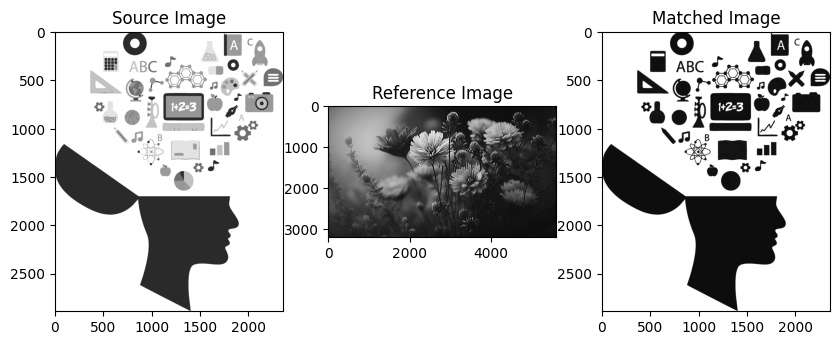

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load the source and reference images
source_img = cv2.imread('/content/brain pngegg (4).png', 0)
reference_img = cv2.imread('/content/natures-beauty-captured-colorful-flower-close-up-generative-ai.jpg', 0)

# Check if images are loaded correctly
if source_img is None:
    print("Error: Source image not loaded.")
    # Handle the error (e.g., raise an exception or exit)
if reference_img is None:
    print("Error: Reference image not loaded.")
    # Handle the error (e.g., raise an exception or exit)

# Proceed if images are loaded
if source_img is not None and reference_img is not None:
    # Compute the histograms and CDFs
    source_hist, bins = np.histogram(source_img.flatten(), 256, [0, 256])
    source_cdf = source_hist.cumsum()

    reference_hist, bins = np.histogram(reference_img.flatten(), 256, [0, 256])
    reference_cdf = reference_hist.cumsum()

    # Normalize the CDFs
    source_cdf_normalized = source_cdf * (255 / source_cdf[-1])
    reference_cdf_normalized = reference_cdf * (255 / reference_cdf[-1])

    # Create the mapping function
    mapping = np.zeros(256)
    for i in range(256):
        closest_value = np.abs(reference_cdf_normalized - source_cdf_normalized[i]).argmin()
        mapping[i] = closest_value

    matched_img = mapping[source_img]

    # Display the images
    plt.figure(figsize=(10, 10))

    plt.subplot(1, 3, 1)
    plt.title('Source Image')
    plt.imshow(source_img, cmap='gray')

    plt.subplot(1, 3, 2)
    plt.title('Reference Image')
    plt.imshow(reference_img, cmap='gray')

    plt.subplot(1, 3, 3)
    plt.title('Matched Image')
    plt.imshow(matched_img, cmap='gray')

    plt.show()


Upload the source image:


Saving WhatsApp Image 2024-09-06 at 1.33.29 PM.jpeg to WhatsApp Image 2024-09-06 at 1.33.29 PM (3).jpeg
Upload the template image:


Saving WhatsApp Image 2024-09-06 at 1.33.29 PM (1).jpeg to WhatsApp Image 2024-09-06 at 1.33.29 PM (1) (3).jpeg


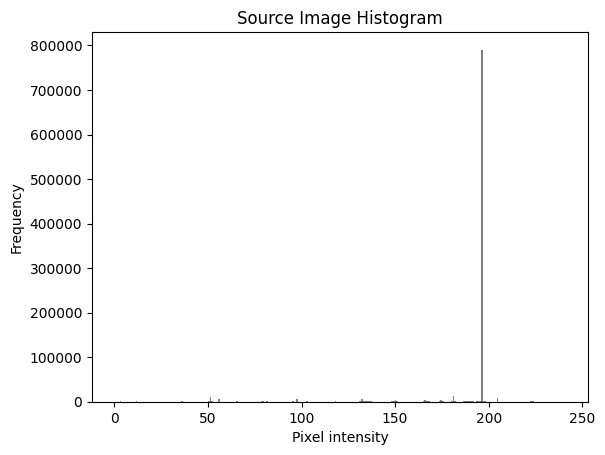

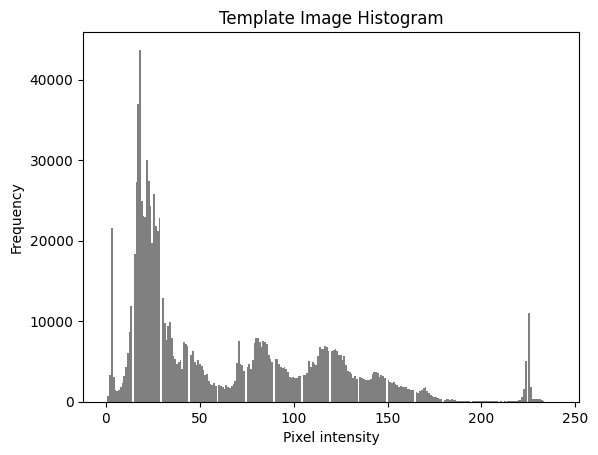

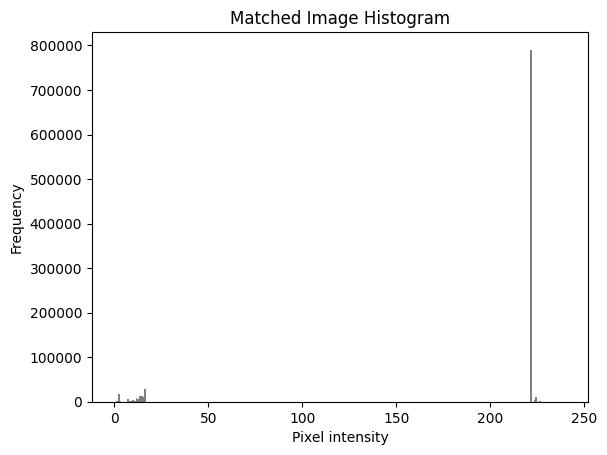

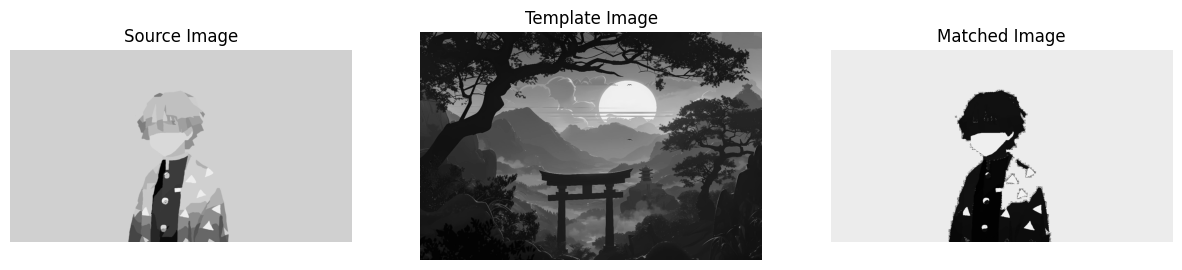

Enter the filename to save the matched image (e.g., matched_image.png): matched_image.png
Matched image saved as matched_image.png


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from PIL import Image
import cv2

# Function for matching the histogram of source image with a template image
def histogram_matching(source, template):
    # Store original shape and flatten both images
    original_shape = source.shape
    source_flat = source.ravel()
    template_flat = template.ravel()

    # Find unique pixel values and their counts for both images
    src_vals, src_counts = np.unique(source_flat, return_counts=True)
    tmpl_vals, tmpl_counts = np.unique(template_flat, return_counts=True)

    # Calculate cumulative distributions (CDFs) for both images
    src_cdf = np.cumsum(src_counts).astype(np.float64) / source_flat.size
    tmpl_cdf = np.cumsum(tmpl_counts).astype(np.float64) / template_flat.size

    # Map source pixels to template based on CDFs
    matched_pixels = np.interp(source_flat, src_vals, np.interp(src_cdf, tmpl_cdf, tmpl_vals))

    # Reshape to original shape
    return matched_pixels.reshape(original_shape)


# Function to plot image histograms
def plot_histogram(image, title):
    plt.figure()
    plt.title(title)
    plt.hist(image.ravel(), bins=256, color='gray')
    plt.xlabel('Pixel intensity')
    plt.ylabel('Frequency')
    plt.show()

# Function to upload an image in Google Colab
def upload_image(prompt):
    print(prompt)
    uploaded = files.upload()  # Upload an image
    if not uploaded:  # If no image is uploaded, return None
        return None
    image_name = list(uploaded.keys())[0]
    image = Image.open(image_name)  # Open image using PIL
    return cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)  # Convert to grayscale

# Upload source and template images
source_image = upload_image("Upload the source image:")
template_image = upload_image("Upload the template image:")

# If images are uploaded, perform histogram matching
if source_image is None or template_image is None:
    print("Error: One of the images was not uploaded.")
else:
    # Perform histogram matching
    matched_image = histogram_matching(source_image, template_image)

    # Plot histograms for comparison
    plot_histogram(source_image, "Source Image Histogram")
    plot_histogram(template_image, "Template Image Histogram")
    plot_histogram(matched_image, "Matched Image Histogram")

    # Display the original and matched images side by side
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.title('Source Image')
    plt.imshow(source_image, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.title('Template Image')
    plt.imshow(template_image, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.title('Matched Image')
    plt.imshow(matched_image, cmap='gray')
    plt.axis('off')
    plt.show()

    # Save the matched image
    output_path = input("Enter the filename to save the matched image (e.g., matched_image.png): ")
    cv2.imwrite(output_path, matched_image)
    print(f"Matched image saved as {output_path}")

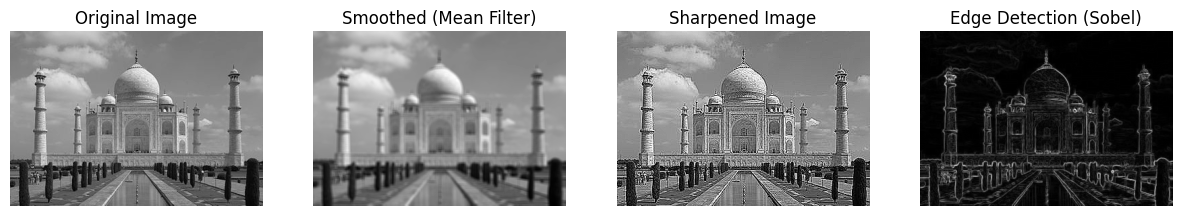

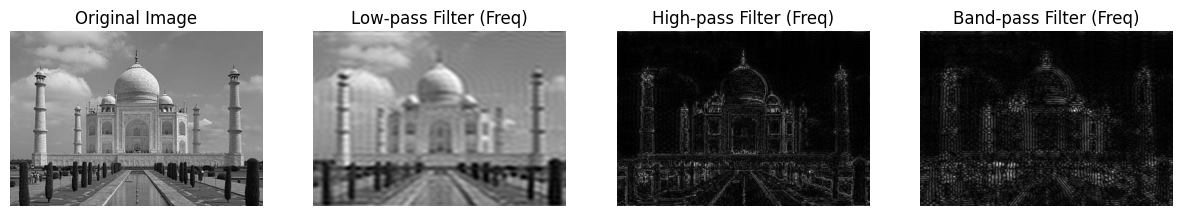

In [ ]:
!pip install numpy opencv-python matplotlib scipy

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy import fftpack

# Utility function to display images
def display_images(images, titles, cmap='gray'):
    plt.figure(figsize=(15, 5))
    for i in range(len(images)):
        plt.subplot(1, len(images), i+1)
        plt.title(titles[i])
        plt.imshow(images[i], cmap=cmap)
        plt.axis('off')
    plt.show()

# SPATIAL FILTERS
# 1. Smoothing (Low-pass) Filter (Mean Filter)
def apply_smoothing_filter(image):
    kernel = np.ones((5,5), np.float32) / 25  # 5x5 mean kernel
    smoothed = cv2.filter2D(image, -1, kernel)
    return smoothed

# 2. Sharpening Filter (Laplacian)
def apply_sharpening_filter(image):
    kernel = np.array([[0, -1, 0],
                       [-1, 5,-1],
                       [0, -1, 0]])
    sharpened = cv2.filter2D(image, -1, kernel)
    return sharpened

# 3. Edge Detection (Sobel Filter)
def apply_edge_detection(image):
    sobelx = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)  # X gradient
    sobely = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)  # Y gradient
    sobel_edge = cv2.magnitude(sobelx, sobely)  # Magnitude of gradients
    return sobel_edge

# FREQUENCY DOMAIN FILTERS
# Convert image to frequency domain using FFT
def to_frequency_domain(image):
    dft = np.fft.fftshift(np.fft.fft2(image))
    return dft

# Convert back to spatial domain
def to_spatial_domain(freq_image):
    inv_dft = np.fft.ifft2(np.fft.ifftshift(freq_image))
    return np.abs(inv_dft)

# 1. Low-pass Filter in Frequency Domain
def apply_low_pass_filter(image):
    freq_image = to_frequency_domain(image)
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2

    # Create a mask with a centered square low-pass region
    mask = np.zeros((rows, cols), np.uint8)
    mask[crow-30:crow+30, ccol-30:ccol+30] = 1

    # Apply mask and inverse DFT
    filtered_dft = freq_image * mask
    low_pass_image = to_spatial_domain(filtered_dft)
    return low_pass_image

# 2. High-pass Filter in Frequency Domain
def apply_high_pass_filter(image):
    freq_image = to_frequency_domain(image)
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2

    # Create a mask with a centered square high-pass region
    mask = np.ones((rows, cols), np.uint8)
    mask[crow-30:crow+30, ccol-30:ccol+30] = 0

    # Apply mask and inverse DFT
    filtered_dft = freq_image * mask
    high_pass_image = to_spatial_domain(filtered_dft)
    return high_pass_image

# 3. Band-pass Filter in Frequency Domain
def apply_band_pass_filter(image):
    freq_image = to_frequency_domain(image)
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2

    # Create a band-pass mask
    mask = np.zeros((rows, cols), np.uint8)
    mask[crow-60:crow+60, ccol-60:ccol+60] = 1
    mask[crow-30:crow+30, ccol-30:ccol+30] = 0  # Block the center for band-pass

    # Apply mask and inverse DFT
    filtered_dft = freq_image * mask
    band_pass_image = to_spatial_domain(filtered_dft)
    return band_pass_image

# Load a grayscale image
image_path = '/content/375px-Taj_Mahal,_Agra,_India_edit3.jpg'  # Replace with your image path
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Apply spatial filters
smoothed_image = apply_smoothing_filter(image)
sharpened_image = apply_sharpening_filter(image)
edge_detected_image = apply_edge_detection(image)

# Apply frequency domain filters
low_pass_image = apply_low_pass_filter(image)
high_pass_image = apply_high_pass_filter(image)
band_pass_image = apply_band_pass_filter(image)

# Display results
display_images([image, smoothed_image, sharpened_image, edge_detected_image],
               ['Original Image', 'Smoothed (Mean Filter)', 'Sharpened Image', 'Edge Detection (Sobel)'])

display_images([image, low_pass_image, high_pass_image, band_pass_image],
               ['Original Image', 'Low-pass Filter (Freq)', 'High-pass Filter (Freq)', 'Band-pass Filter (Freq)'])

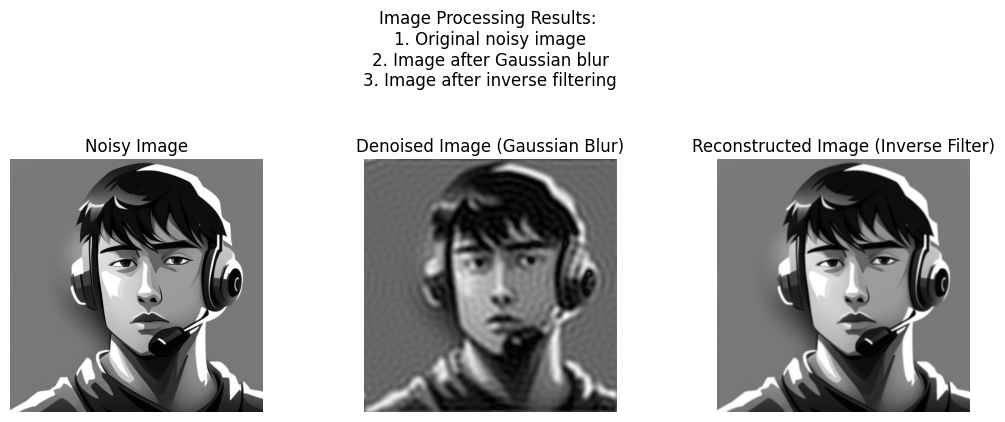

In [ ]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Load a noisy image in grayscale
img_noisy = cv2.imread('/content/image (3).png', 0)

# 1. Noise Removal using Gaussian Blur (Spatial Domain)
denoised_img = cv2.GaussianBlur(img_noisy, (5, 5), 0)

# 2. Inverse Filtering in Frequency Domain

# Perform DFT (Discrete Fourier Transform)
dft = cv2.dft(np.float32(denoised_img), flags=cv2.DFT_COMPLEX_OUTPUT)
dft_shift = np.fft.fftshift(dft)

# Create a simple low-pass filter in the frequency domain
rows, cols = denoised_img.shape
crow, ccol = rows // 2, cols // 2
mask = np.zeros((rows, cols, 2), np.float32)
r = 30  # Radius for low-pass filter
center = [crow, ccol]
x, y = np.ogrid[:rows, :cols]
mask_area = (x - center[0]) ** 2 + (y - center[1]) ** 2 <= r * r
mask[mask_area] = 1

# Apply mask to the DFT shifted image
fshift = dft_shift * mask

# Inverse DFT to reconstruct the image
f_ishift = np.fft.ifftshift(fshift)
img_back = cv2.idft(f_ishift)
img_back = cv2.magnitude(img_back[:, :, 0], img_back[:, :, 1])

# Display the results
plt.figure(figsize=(12, 8))

# Set padding between subplots
plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, hspace=0.4, wspace=0.4)

# Subplot 1: Noisy Image
plt.subplot(1, 3, 1)
plt.imshow(img_noisy, cmap='gray')
plt.title('Noisy Image')
plt.axis('off')

# Subplot 2: Denoised Image
plt.subplot(1, 3, 3)
plt.imshow(denoised_img, cmap='gray')
plt.title('Reconstructed Image (Inverse Filter)')
plt.axis('off')

# Subplot 3: Reconstructed Image
plt.subplot(1, 3, 2)
plt.imshow(img_back, cmap='gray')
plt.title('Denoised Image (Gaussian Blur)')
plt.axis('off')

# Add a text output below the images
plt.figtext(0.5, 0.75, 'Image Processing Results: \n1. Original noisy image\n2. Image after Gaussian blur\n3. Image after inverse filtering',
            ha='center', fontsize=12)

plt.show()


Saving WhatsApp Image 2024-09-06 at 1.33.29 PM (1).jpeg to WhatsApp Image 2024-09-06 at 1.33.29 PM (1) (1).jpeg


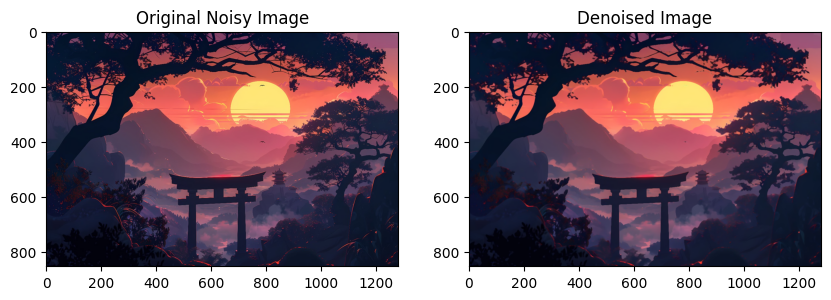

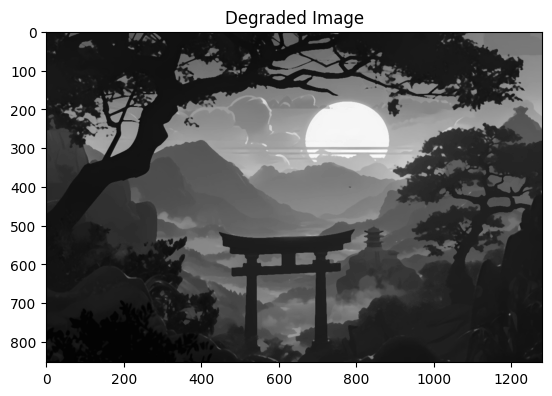

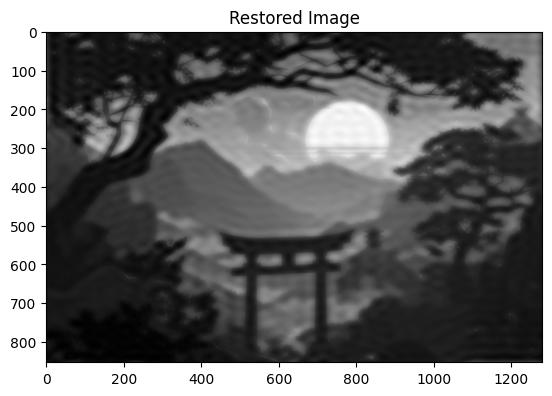

True

In [ ]:
!pip install opencv-python-headless
from google.colab import files

uploaded = files.upload()  # Use this to upload the noisy or degraded image
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image (you can replace 'input_image.jpg' with the filename you uploaded)
image = cv2.imread('/content/WhatsApp Image 2024-09-06 at 1.33.29 PM (1).jpeg')

# Apply median filter for noise removal (kernel size 5)
denoised_image = cv2.medianBlur(image, 5)

# Display the original and denoised images
plt.figure(figsize=(10,5))
plt.subplot(1,2,1), plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB)), plt.title('Original Noisy Image')
plt.subplot(1,2,2), plt.imshow(cv2.cvtColor(denoised_image, cv2.COLOR_BGR2RGB)), plt.title('Denoised Image')
plt.show()

# Save the denoised image
cv2.imwrite('/content/WhatsApp Image 2024-09-06 at 1.33.29 PM (1).jpeg',denoised_image)
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the degraded (blurred) image in grayscale
degraded_image = cv2.imread('/content/WhatsApp Image 2024-09-06 at 1.33.29 PM (1).jpeg', cv2.IMREAD_GRAYSCALE)

# Display the degraded image
plt.imshow(degraded_image, cmap='gray'), plt.title('Degraded Image')
plt.show()

# Apply Fourier Transform to the degraded image
degraded_fft = np.fft.fft2(degraded_image)
degraded_fft_shifted = np.fft.fftshift(degraded_fft)

# Create a simple degradation function and noise spectrum (this is an example)
rows, cols = degraded_image.shape
crow, ccol = rows // 2, cols // 2
degradation_function = np.ones_like(degraded_fft_shifted)
degradation_function[crow-30:crow+30, ccol-30:ccol+30] = 0.1  # Simulating blurring effect

# Assume a noise spectrum
noise_spectrum = np.ones_like(degraded_fft_shifted) * 0.01

# Apply inverse filtering
inverse_filter = np.conj(degradation_function) / (np.abs(degradation_function)**2 +
noise_spectrum)
restored_fft = degraded_fft_shifted * inverse_filter

# Perform Inverse Fourier Transform to obtain the restored image
restored_fft_shifted = np.fft.ifftshift(restored_fft)
restored_image = np.fft.ifft2(restored_fft_shifted)
restored_image = np.abs(restored_image)

# Display the restored image
plt.imshow(restored_image, cmap='gray'), plt.title('Restored Image')
plt.show()

# Save the restored image
cv2.imwrite('/content/WhatsApp Image 2024-09-06 at 1.33.29 PM (1).jpeg',restored_image)

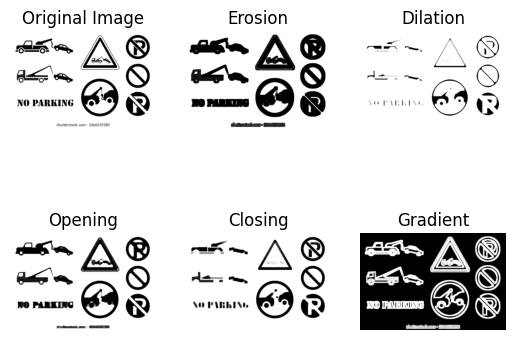

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread('/content/attention-forbidden-no-parking-
zone-260nw-1066519280.webp', cv2.IMREAD_GRAYSCALE)
kernel = np.ones((5, 5), np.uint8)
erosion=cv2.erode(image, kernel, iterations=1)
cv2.imwrite('erosion.jpg', erosion)
dilation = cv2.dilate (image, kernel, iterations=1)
cv2.imwrite('dilation.jpg', dilation)
opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
cv2.imwrite('opening.jpg', opening)
closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)
cv2.imwrite('closing.jpg', closing)
gradient = cv2.morphologyEx(image, cv2.MORPH_GRADIENT, kernel)
cv2.imwrite('gradient.jpg', gradient)
titles = ['Original Image', 'Erosion', 'Dilation', 'Opening', 'Closing', 'Gradient']
images =[image, erosion, dilation, opening, closing, gradient]
for i in range(6):
  plt.subplot(2, 3, i+1)
  plt.imshow(images[i], cmap='gray')
  plt.title(titles[i])
  plt.axis('off')
plt.show()

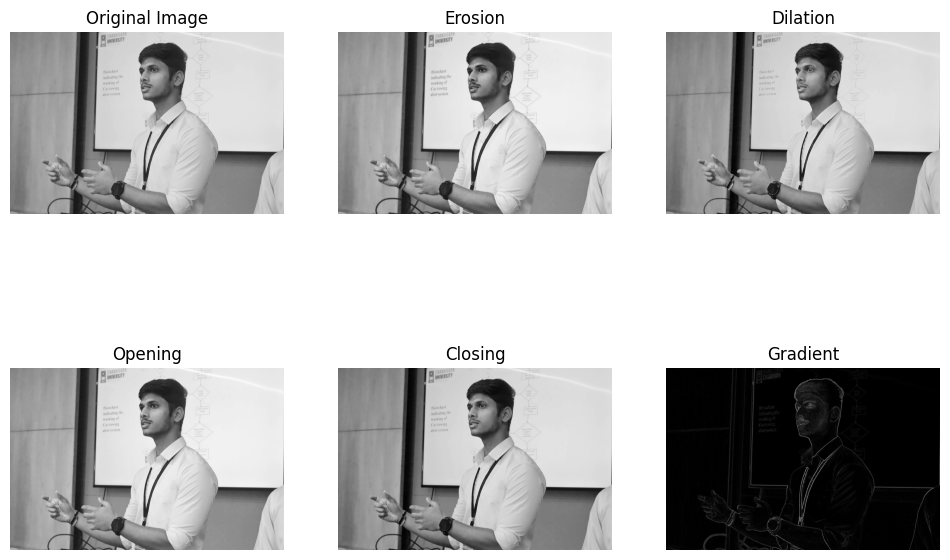

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Reading the image in grayscale mode
image = cv2.imread('/content/WhatsApp Image 2024-09-25 at
00.51.47_1cc75c45.jpg', cv2.IMREAD_GRAYSCALE)

# Creating a 5x5 kernel
kernel = np.ones((5, 5), np.uint8)

# Applying morphological transformations
erosion = cv2.erode(image, kernel, iterations=1)
dilation = cv2.dilate(image, kernel, iterations=1)
opening = cv2.morphologyEx(image, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)
gradient = cv2.morphologyEx(image, cv2.MORPH_GRADIENT, kernel)

# Titles and images for displaying
titles = ['Original Image', 'Erosion', 'Dilation', 'Opening', 'Closing', 'Gradient']
images = [image, erosion, dilation, opening, closing, gradient]

# Increase figure size
plt.figure(figsize=(12, 8))  # Width = 12 inches, Height = 8 inches

# Loop to plot the images
for i in range(6):
    plt.subplot(2, 3, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

# Display the plots
plt.show()


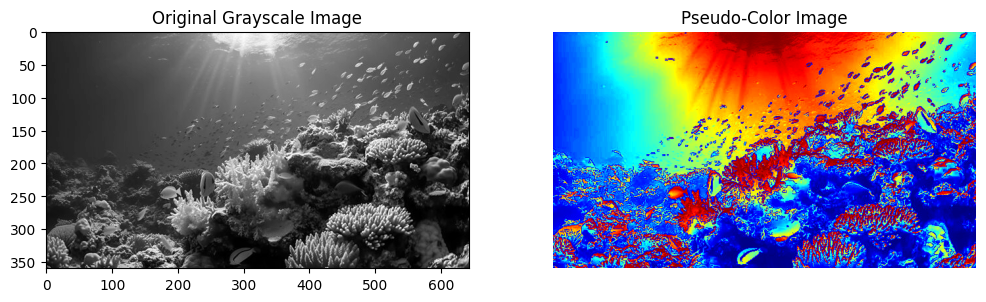

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Load grayscale medical image (X-ray or MRI)
image = cv2.imread('/content/360_F_599654271_ymVkvUL1hasHyiiAeVjXYHKF09HMqjAo.jpg', cv2.IMREAD_GRAYSCALE)

# Step 2: Apply Histogram Equalization for global contrast improvement
equalized_image = cv2.equalizeHist(image)

# Step 3: Apply a color map (e.g., applying a predefined color scheme)
# Use OpenCV's in-built colormap for visualization (e.g., COLORMAP_JET)
pseudo_color_image = cv2.applyColorMap(equalized_image, cv2.COLORMAP_JET)

# Step 4: Adaptive Color Mapping (optional step for enhanced ROI)
def adaptive_colormap(image):
    # Normalize the image to the range [0, 1]
    normalized_image = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # Apply the color map based on intensity ranges
    return cv2.applyColorMap(normalized_image, cv2.COLORMAP_PARULA)

# Step 5: Edge enhancement (highlight boundaries in medical images)
edges = cv2.Canny(equalized_image, 100, 200)
pseudo_color_image[edges > 0] = [255, 0, 0]  # Color edges in red for visualization

# Step 6: Display the results
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Grayscale Image')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(pseudo_color_image, cv2.COLOR_BGR2RGB))
plt.title('Pseudo-Color Image')
plt.axis('off')

plt.show()


Enter the path to the image for skin detection: /content/360_F_599654271_ymVkvUL1hasHyiiAeVjXYHKF09HMqjAo.jpg

Skin Detection Results:


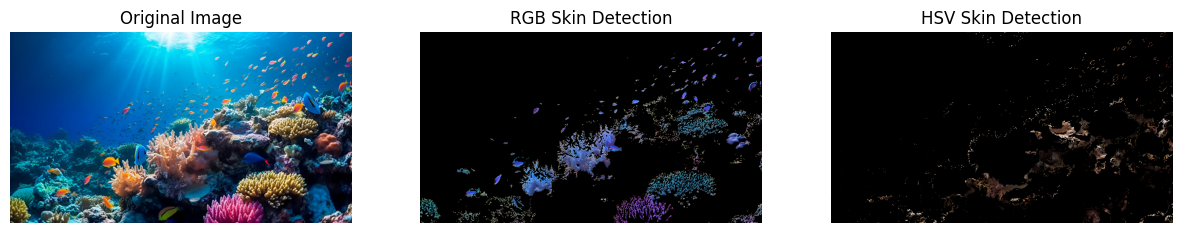

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

class SkinDetector:
    def __init__(self):  # Fixed the constructor name
        self.rgb_min = np.array([95, 40, 20], dtype=np.uint8)
        self.rgb_max = np.array([255, 170, 170], dtype=np.uint8)
        self.hsv_min = np.array([0, 15, 0], dtype=np.uint8)
        self.hsv_max = np.array([17, 170, 255], dtype=np.uint8)

    def detect_all(self, image):
        # Apply RGB skin detection mask
        mask_rgb = cv2.inRange(image, self.rgb_min, self.rgb_max)
        # Convert to HSV color space
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        # Apply HSV skin detection mask
        mask_hsv = cv2.inRange(hsv, self.hsv_min, self.hsv_max)

        # Return masked images for both RGB and HSV
        return {
            'rgb': cv2.bitwise_and(image, image, mask=mask_rgb),
            'hsv': cv2.bitwise_and(image, image, mask=mask_hsv),
        }

def display_skin_detection_results(image):
    img = cv2.imread(image)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
    detector = SkinDetector()
    results = detector.detect_all(img)

    # Display the results
    plt.figure(figsize=(15, 10))
    plt.subplot(231)
    plt.title('Original Image')
    plt.imshow(img)
    plt.axis('off')

    plt.subplot(232)
    plt.title('RGB Skin Detection')
    plt.imshow(cv2.cvtColor(results['rgb'], cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(233)
    plt.title('HSV Skin Detection')
    plt.imshow(cv2.cvtColor(results['hsv'], cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.show()

if __name__ == "__main__":  # Fixed the main block identifier
    skin_detection_image_path = input("Enter the path to the image for skin detection: ")  # Input image path
    print("\nSkin Detection Results:")
    display_skin_detection_results(skin_detection_image_path)


Enter the path to the image file: /content/360_F_599654271_ymVkvUL1hasHyiiAeVjXYHKF09HMqjAo.jpg


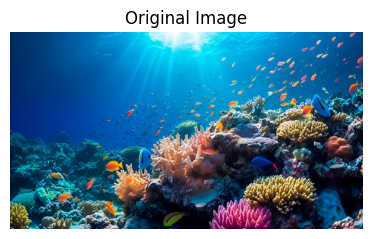

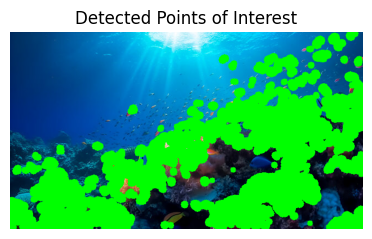

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def point_detection(image_path, k=0.04, threshold=0.01):
    # Load image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Image not found or unable to load.")

    # Convert image to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Gaussian blur to reduce noise
    blurred_image = cv2.GaussianBlur(gray_image, (5, 5), 0)

    # Compute image gradients
    Ix = cv2.Sobel(blurred_image, cv2.CV_64F, 1, 0, ksize=5)  # Gradient in x direction
    Iy = cv2.Sobel(blurred_image, cv2.CV_64F, 0, 1, ksize=5)  # Gradient in y direction

    # Compute second moment matrix components
    Ixx = Ix ** 2
    Iyy = Iy ** 2
    Ixy = Ix * Iy

    # Define window size
    window_size = 3
    height, width = gray_image.shape
    harris_response = np.zeros((height, width), dtype=np.float32)

    # Compute Harris response for each pixel
    for y in range(window_size, height - window_size):
        for x in range(window_size, width - window_size):
            Sxx = np.sum(Ixx[y-window_size:y+window_size+1, x-window_size:x+window_size+1])
            Syy = np.sum(Iyy[y-window_size:y+window_size+1, x-window_size:x+window_size+1])
            Sxy = np.sum(Ixy[y-window_size:y+window_size+1, x-window_size:x+window_size+1])

            determinant = (Sxx * Syy) - (Sxy ** 2)
            trace = Sxx + Syy
            R = determinant - k * (trace ** 2)
            harris_response[y, x] = R

    # Threshold Harris response to detect points
    points_of_interest = np.argwhere(harris_response > threshold * harris_response.max())

    # Draw points of interest on the image
    image_with_points = image.copy()
    for point in points_of_interest:
        cv2.circle(image_with_points, (point[1], point[0]), 5, (0, 255, 0), -1)

    # Display the original image
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image')
    plt.axis('off')
    plt.show()

    # Display the image with detected points
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(image_with_points, cv2.COLOR_BGR2RGB))
    plt.title('Detected Points of Interest')
    plt.axis('off')
    plt.show()

# Main function to take user input
if __name__ == "__main__":
    image_path = input("Enter the path to the image file: ")
    point_detection(image_path)

Enter the path to the image file: /content/car-line-art-260nw-110920835.webp


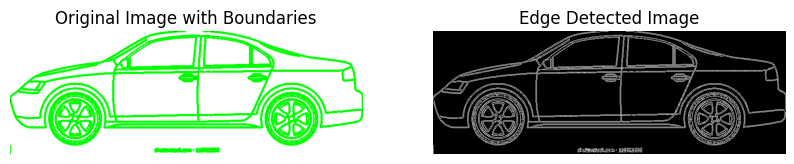

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def boundary_linking(edge_image):
    # Initialize an empty list to store boundaries
    boundaries = []

    # Create a visited array to mark visited pixels
    visited = np.zeros(edge_image.shape, dtype=bool)

    # Define 8-connected neighborhood
    neighbors = [(-1, -1), (-1, 0), (-1, 1), (0, -1), (0, 1), (1, -1), (1, 0), (1, 1)]

    def is_valid(x, y):
        return 0 <= x < edge_image.shape[1] and 0 <= y < edge_image.shape[0] and edge_image[y, x] == 255 and not visited[y, x]

    def follow_edge(x, y):
        boundary = [(x, y)]
        visited[y, x] = True
        stack = [(x, y)]

        while stack:
            cx, cy = stack.pop()
            for dx, dy in neighbors:
                nx, ny = cx + dx, cy + dy
                if is_valid(nx, ny):
                    visited[ny, nx] = True
                    boundary.append((nx, ny))
                    stack.append((nx, ny))

        return boundary

    # Iterate through each pixel in the edge image
    for y in range(edge_image.shape[0]):
        for x in range(edge_image.shape[1]):
            if edge_image[y, x] == 255 and not visited[y, x]:
                boundary = follow_edge(x, y)
                boundaries.append(boundary)

    return boundaries

def process_image(image_path):
    # Load image
    image = cv2.imread(image_path)
    if image is None:
        raise ValueError("Image not found or unable to load.")

    # Convert to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Apply Canny edge detection
    edges = cv2.Canny(gray_image, 100, 200)

    # Perform boundary linking
    boundaries = boundary_linking(edges)

    # Draw boundaries on the original image
    for boundary in boundaries:
        for point in boundary:
            cv2.circle(image, point, 1, (0, 255, 0), -1)

    return image, edges

# Main function to take user input
if __name__ == "__main__":
    image_path = input("Enter the path to the image file: ")
    original_image, edge_image = process_image(image_path)

    # Display the original image
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    plt.title('Original Image with Boundaries')
    plt.axis('off')

    # Display the edge-detected image
    plt.subplot(1, 2, 2)
    plt.imshow(edge_image, cmap='gray')
    plt.title('Edge Detected Image')
    plt.axis('off')

    plt.show()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 28ms/step - accuracy: 0.3409 - loss: 1.7812 - val_accuracy: 0.5333 - val_loss: 1.2969
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.5717 - loss: 1.2096 - val_accuracy: 0.6144 - val_loss: 1.0918
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 28ms/step - accuracy: 0.6411 - loss: 1.0155 - val_accuracy: 0.6398 - val_loss: 1.0354
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 29ms/step - accuracy: 0.6797 - loss: 0.9080 - val_accuracy: 0.6758 - val_loss: 0.9378
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 43s 28ms/step - accuracy: 0.7105 - loss: 0.8259 - val_accuracy: 0.6871 - val_loss: 0.9075
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 27ms/step - accuracy: 0.7271 - loss: 0.7722 - val_accuracy: 0.6948 - val_loss: 0.8880
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 44s 28ms/step - accuracy: 0.7490 - loss: 0.7123 - val_accuracy: 0.6956 - val_loss: 0.8752
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 28ms/step - accuracy: 0.7640 -

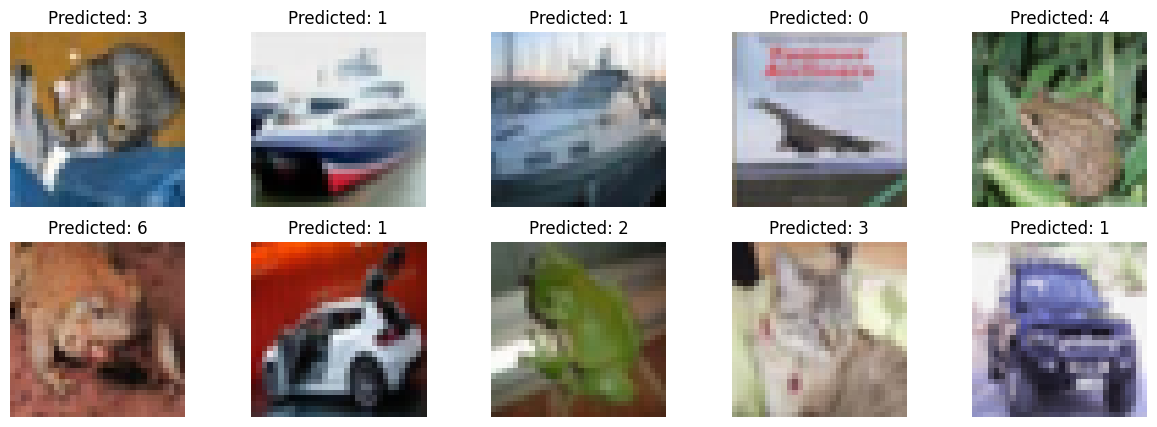

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load and preprocess the dataset
def load_data():
    (train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()
    train_images, test_images = train_images / 255.0, test_images / 255.0
    return train_images, train_labels, test_images, test_labels

# Build the CNN model
def build_model():
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.Flatten())
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dense(10))  # 10 classes for CIFAR-10
    return model

# Compile and train the model
def compile_and_train(model, train_images, train_labels, test_images, test_labels):
    model.compile(optimizer='adam',
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])
    history = model.fit(train_images, train_labels, epochs=10,
                        validation_data=(test_images, test_labels))
    return history

# Evaluate the model
def evaluate_model(model, test_images, test_labels):
    test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
    print(f"Test accuracy: {test_acc}")

# Display some original images and their predictions
def display_predictions(model, test_images, test_labels):
    predictions = model.predict(test_images)
    predicted_classes = np.argmax(predictions, axis=1)

    # Display 10 images with their predicted classes
    plt.figure(figsize=(15, 5))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(test_images[i])
        plt.title(f'Predicted: {predicted_classes[i]}')
        plt.axis('off')
    plt.show()

# Main function to run the steps
def main():
    train_images, train_labels, test_images, test_labels = load_data()
    model = build_model()
    compile_and_train(model, train_images, train_labels, test_images, test_labels)
    evaluate_model(model, test_images, test_labels)
    display_predictions(model, test_images, test_labels)

if __name__ == "__main__":
    main()

In [ ]:
pip install opencv-python matplotlib numpy

Enter the path to the image file: /content/premium_photo-1664474619075-644dd191935f.jpg


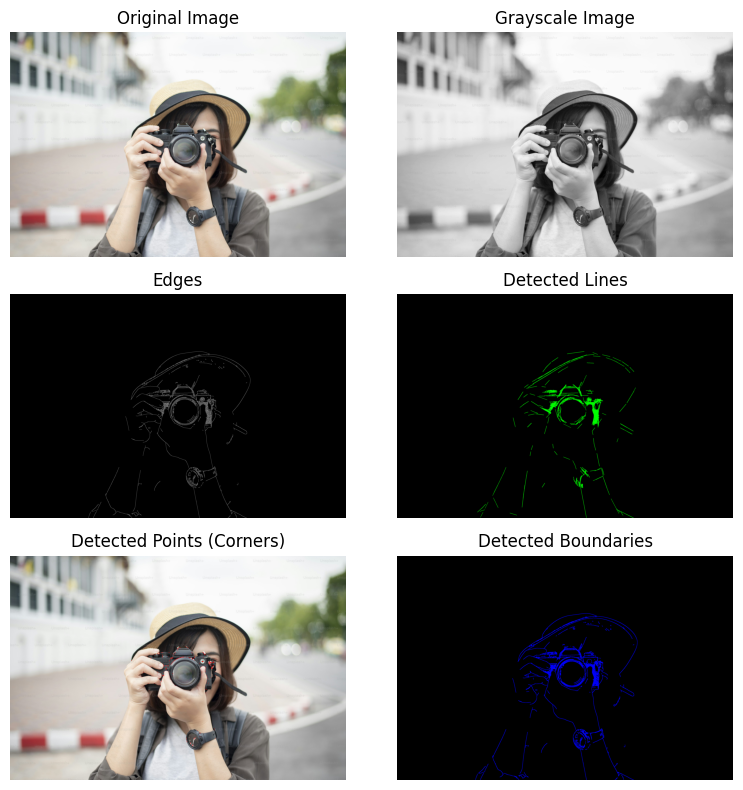

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def main():
    image_path = input("Enter the path ")
    image = cv2.imread(image_path)
    if image is None:
        print("Error:not find the image.")
        return

    #image to RGB
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    #image to gray
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    plt.figure(figsize=(8, 8))
    plt.subplot(3, 2, 1)
    plt.imshow(image_rgb)
    plt.title('Original Image')
    plt.axis('off')

    # gray image
    plt.subplot(3, 2, 2)
    plt.imshow(gray_image, cmap='gray')
    plt.title('Grayscale Image')
    plt.axis('off')

    # Edge Detection using Canny
    edges = cv2.Canny(image, 100, 200)
    plt.subplot(3, 2, 3)
    plt.imshow(edges, cmap='gray')
    plt.title('Edges')
    plt.axis('off')

    # Line Detection using Hough Transform
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=50, minLineLength=30, maxLineGap=10)

    line_image = np.zeros_like(image)
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            cv2.line(line_image, (x1, y1), (x2, y2), (0, 255, 0), 2)

    plt.subplot(3, 2, 4)
    plt.imshow(cv2.cvtColor(line_image, cv2.COLOR_BGR2RGB))
    plt.title('Detected Lines')
    plt.axis('off')

    # Point Detection using Harris Corner Detection
    corners = cv2.cornerHarris(gray_image, blockSize=2, ksize=3, k=0.04)
    corners = cv2.dilate(corners, None)

    # Mark corners on the original image
    image[corners > 0.01 * corners.max()] = [0, 0, 255]  # Mark corners in red
    plt.subplot(3, 2, 5)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title('Detected Points (Corners)')
    plt.axis('off')

    # Boundary Detection using findContours
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    boundary_image = np.zeros_like(image)
    cv2.drawContours(boundary_image, contours, -1, (255, 0, 0), 2)  # Draw contours in blue

    plt.subplot(3, 2, 6)
    plt.imshow(cv2.cvtColor(boundary_image, cv2.COLOR_BGR2RGB))
    plt.title('Detected Boundaries')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()